#***Handling Outliers***
This module detects and treats outliers in the numerical columns of the dataset using the IQR(Interquartile Range) method.
Outliers are extreme values that can negatively afect model so cap them to ensure clean,reliable data for model training.

#**1.Import Libraries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
%matplotlib inline

**Why:** Loads required libraries for data handling, numerical operations, and visualiztion.

#**2.Mount Drive & Load Dataset**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Crop_recommendation.csv')

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


**Why:** Connects Google Drive and loads the dataset for outlier analysis.

#**3.View Summary Statistics**

In [11]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


**Why:** Displays count,mean,standard deviation,min,max, and quartile values for each numerical column - useful for understanding data distribution before checking for outliers.

#**4.Visualize Outliers with Boxplots**

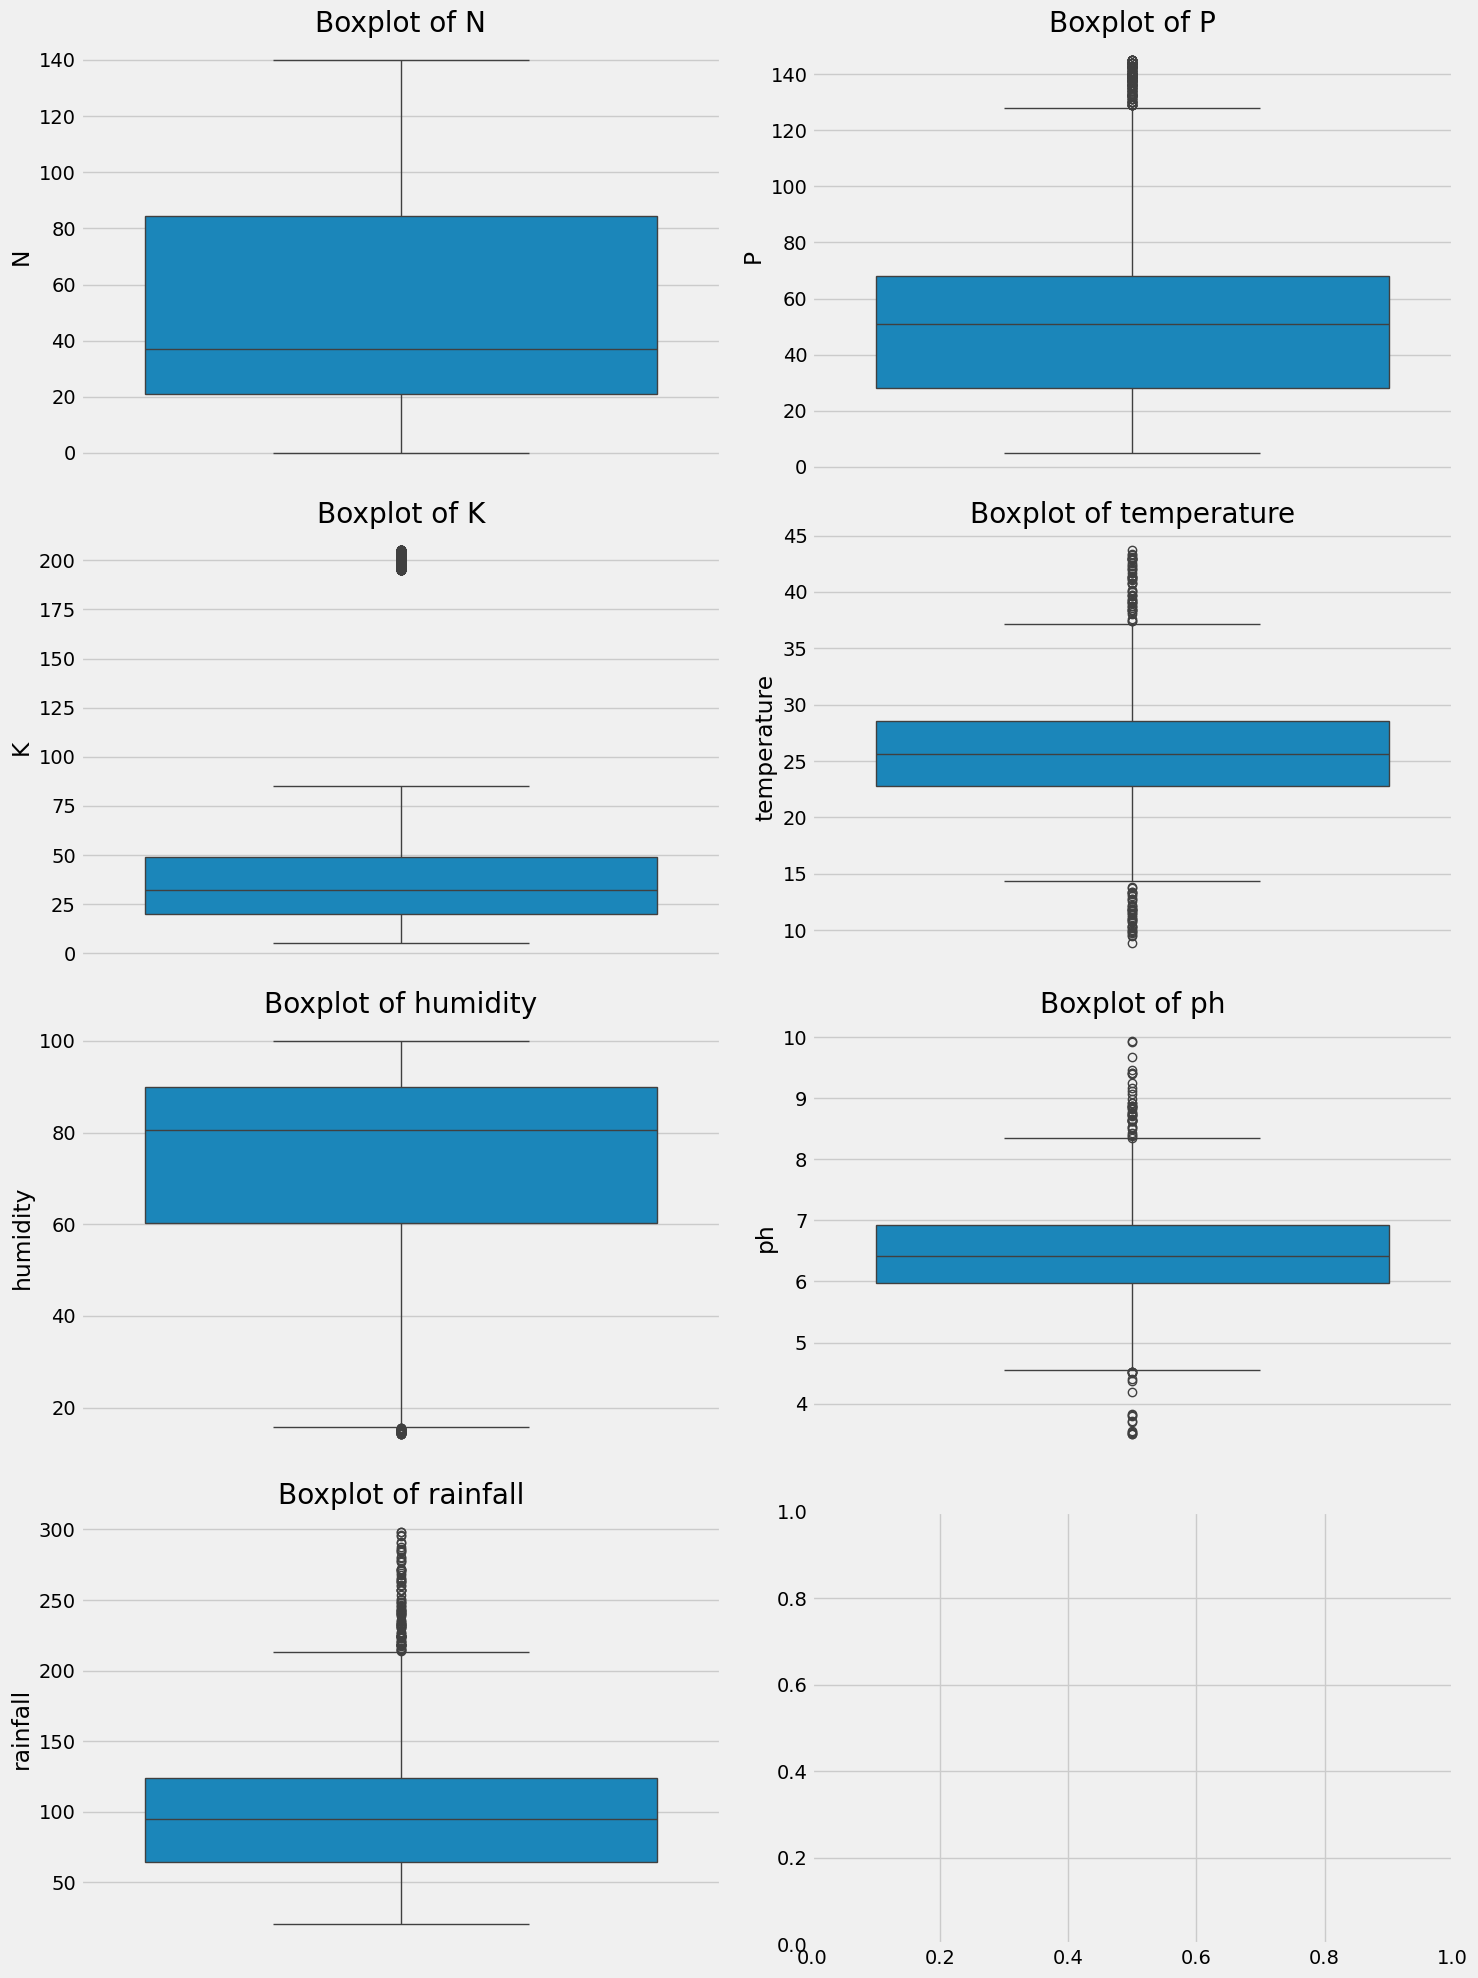

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(15,20))
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for i, col in enumerate(columns):
    row = i // 2
    col_pos = i % 2
    sns.boxplot(y=data[col], ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Why:** Boxplots visually highlight extreme values ( dots outside the whiskers) for each numerical feature.

#**5.Detect Outliers Using IQR Method**

In [17]:
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found(Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f})")

N: 0 outliers found(Lower: -73.88, Upper: 179.12)
P: 0 outliers found(Lower: -32.00, Upper: 128.00)
K: 0 outliers found(Lower: -23.50, Upper: 92.50)
temperature: 0 outliers found(Lower: 14.08, Upper: 37.25)
humidity: 0 outliers found(Lower: 15.73, Upper: 134.48)
ph: 0 outliers found(Lower: 4.54, Upper: 8.35)
rainfall: 0 outliers found(Lower: -25.02, Upper: 213.84)


**Why:**  Calculates statistical bounds and counts how many records fall outside the normal range for each column.

#**6.Cap (Treat) the Outliers**

In [15]:
def cap_outliers(df,col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
  return df

for col in columns:
  data = cap_outliers(data,col)

print("Outliers capped successfully!")

Outliers capped successfully!


**Why:** Instead of deleting outlier rows, extreme values are capped to the lower/upper bound limits, retaining all records.

#**7.Verify Outliers Are Removed**

In [16]:
for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found")

N: 0 outliers found
P: 0 outliers found
K: 0 outliers found
temperature: 0 outliers found
humidity: 0 outliers found
ph: 0 outliers found
rainfall: 0 outliers found


**Why:** Re-runs the IQR check to confirm capping was successful.

###**Conclusion:**
All outliers across the 7 numerical columns were successfully detected using the IQR metjod and treated using capping, resulting in a cleaner dataset ready fro model training.

This module was completed by **Vani Vasantha Laxmi Yepparika** as part of the Data Preprocessing phase of the Opticrop Project, focused on detecting and handling outliers in the dataset.